In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import os
import csv
import gc
import random
import matplotlib.pyplot as plt

from tqdm import tqdm
from glob import glob
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

from sklearn.model_selection import train_test_split

In [3]:
def plot_sample(X):

    nb_rows = 3
    nb_cols = 3
    fig, axs = plt.subplots(nb_rows, nb_cols, figsize=(6, 6))

    for i in range(0, nb_rows):
        for j in range(0, nb_cols):
            axs[i, j].xaxis.set_ticklabels([])
            axs[i, j].yaxis.set_ticklabels([])
            axs[i, j].imshow(X[random.randint(0, X.shape[0] - 1)])


def read_data(path_list, im_size=(224, 224)):
    
    X = []
    y = []

    tag2idx = {tag.split(os.path.sep)[-1]: i for i, tag in enumerate(path_list)}

    for path in path_list:
        for im_file in tqdm(glob(path + "*/*")):  
            try:
           
                label = im_file.split(os.path.sep)[-2]
                im = cv2.imread(im_file, cv2.IMREAD_COLOR)
            
                im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
               
                im = cv2.resize(im, im_size, interpolation=cv2.INTER_AREA)
                X.append(im)
                y.append(tag2idx[label])  
            except Exception as e:
                
                print("Not picture")

    X = np.array(X) 
    y = np.eye(len(np.unique(y)))[y].astype(np.uint8)

    return X, y

def get_callbacks(weights_file, patience, lr_factor):
    
    return [
        
        ModelCheckpoint(
            filepath=weights_file,
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
        ),

        EarlyStopping(monitor="val_loss", mode="min", patience=patience, verbose=1),
    ]


In [4]:
INPUT_SHAPE = (224, 224, 3)
IM_SIZE = (224, 224)
NUM_EPOCHS = 25
BATCH_SIZE = 4
TEST_SPLIT = 0.2
VAL_SPLIT = 0.2
RANDOM_STATE = 2021
WEIGHTS_FILE = "weightsweeds.h5"  

PATH_LIST = [
    "/Users/PMLS/Desktop/NIRRE/Broadleaf/",
    "/Users/PMLS/Desktop/NIRRE/Crop/",
    "/Users/PMLS/Desktop/NIRRE/Sedge/",

]

In [7]:
i = 0
for path in PATH_LIST:
    PATH_LIST[i] = str(
        Path(Path.cwd()).parents[0].joinpath("/Users/PMLS/Desktop/NIRRE/try/").joinpath(path)
    )
    i += 1
X, y = read_data(PATH_LIST, IM_SIZE)

100%|████████████████████████████████████████████████████████████████████████████████| 112/112 [00:01<00:00, 59.68it/s]


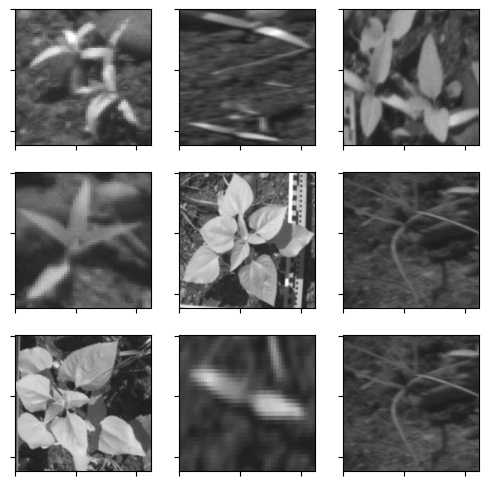

In [12]:
plot_sample(X)

In [8]:
def get_architecture(y, Model_version, as_feature_extractor):

    
    if Model_version == "EfficientNetV2B0":
        feature_extractor = EfficientNetV2B0(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "EfficientNetV2B0":
        feature_extractor = EfficientNetV2B0(
            weights="imagenet",  
            include_top=False, 
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "EfficientNetV2B1":
        feature_extractor = EfficientNetV2B1(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "EfficientNetV2B2":
        feature_extractor = EfficientNetV2B2(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "EfficientNetV2B3":
        feature_extractor = EfficientNetV2B3(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "MobileNetV2":
        feature_extractor = MobileNetV2(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "EfficientNetB0":
        feature_extractor = EfficientNetB0(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "EfficientNetB1":
        feature_extractor = EfficientNetB1(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "EfficientNetB2":
        feature_extractor = EfficientNetB2(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "EfficientNetB3":
        feature_extractor = EfficientNetB3(
            weights="imagenet", 
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "EfficientNetB4":
        feature_extractor = EfficientNetB4(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "DenseNet121":
        feature_extractor = DenseNet121(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "DenseNet169":
        feature_extractor = DenseNet169(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "DenseNet201":
        feature_extractor = DenseNet201(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "MobileNet":
        feature_extractor = MobileNet(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )

    elif Model_version == "NASNetMobile":
        feature_extractor = NASNetMobile(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
        
    elif Model_version == "NASNetLarge":
        feature_extractor = NASNetLarge(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )        

    elif Model_version == "EfficientNetV2S":
        feature_extractor = EfficientNetV2S(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "InceptionV3":
        feature_extractor = InceptionV3(
            weights="imagenet", 
            include_top=False,  
            input_shape=INPUT_SHAPE,
            )
    elif Model_version == "Xception":
        feature_extractor = Xception(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "ResNet50V2":
        feature_extractor = ResNet50V2(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "ResNet50":
        feature_extractor = ResNet50(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )

    elif Model_version == "MobileNetV3Large":
        feature_extractor = MobileNetV3Large(
            weights="imagenet", 
            include_top=False, 
            input_shape=INPUT_SHAPE,
        )
    elif Model_version == "MobileNetV3Small":
        feature_extractor = MobileNetV3Small(
            weights="imagenet",  
            include_top=False,  
            input_shape=INPUT_SHAPE,
        )



    if as_feature_extractor:
        feature_extractor.trainable = False
    else:
        feature_extractor.trainable = True  

    x = layers.GlobalAveragePooling2D(name="pool")(
        feature_extractor.output
    )  
    x = layers.Dense(units=64, activation="relu")(x)  
    
    x = layers.Dropout(0.3)(x)  
    out = layers.Dense(units=y.shape[1], activation="softmax")(x)
    model = Model(feature_extractor.input, out)  

    base_learning_rate = 1e-2
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.SGD(lr=base_learning_rate),
        metrics=["accuracy"],
    )

    return model

In [ ]:
X_prep = tf.keras.applications.mobilenet_v3.preprocess_input(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SPLIT, 
    shuffle=True, 
    stratify=y, 
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VAL_SPLIT,
    shuffle=True,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

In [21]:
model = get_architecture(y, Model_version="MobileNetV2", as_feature_extractor=True)

In [23]:

history_MobileNetV2_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)

final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV2 (Feature Extraction) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 13s 92ms/step - loss: 0.9526 - accuracy: 0.6094 - val_loss: 0.7925 - val_accuracy: 0.6562
Epoch 2/25
96/96 [==============================] - 7s 78ms/step - loss: 0.7569 - accuracy: 0.6901 - val_loss: 0.6853 - val_accuracy: 0.6875
Epoch 3/25
96/96 [==============================] - 7s 77ms/step - loss: 0.7408 - accuracy: 0.6927 - val_loss: 0.6553 - val_accuracy: 0.7604
Epoch 4/25
96/96 [==============================] - 7s 74ms/step - loss: 0.6808 - accuracy: 0.6979 - val_loss: 0.6391 - val_accuracy: 0.7604
Epoch 5/25
96/96 [==============================] - 7s 72ms/step - loss: 0.6237 - accuracy: 0.7344 - val_loss: 0.6954 - val_accuracy: 0.6979
Epoch 6/25
96/96 [==============================] - 7s 75ms/step - loss: 0.6136 - accuracy: 0.7240 - val_loss: 0.5602 - val_accuracy: 0.7604
Epoch 7/25
96/96 [==============================] - 8s 80ms/step - loss: 0.5587 - accuracy: 0.7578 - val_loss: 0.5925 - val_accuracy: 0.7812
Epoch 8/25
9

In [46]:
model = get_architecture(y, Model_version="EfficientNetB0", as_feature_extractor=True)

In [48]:

history_EfficientNetB0_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetB0 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 34s 234ms/step - loss: 0.6917 - accuracy: 0.7135 - val_loss: 0.3815 - val_accuracy: 0.8958
Epoch 2/25
96/96 [==============================] - 19s 202ms/step - loss: 0.3727 - accuracy: 0.8750 - val_loss: 0.2721 - val_accuracy: 0.9271
Epoch 3/25
96/96 [==============================] - 18s 192ms/step - loss: 0.2487 - accuracy: 0.9245 - val_loss: 0.2514 - val_accuracy: 0.9062
Epoch 4/25
96/96 [==============================] - 18s 191ms/step - loss: 0.2274 - accuracy: 0.9323 - val_loss: 0.2353 - val_accuracy: 0.9167
Epoch 5/25
96/96 [==============================] - 19s 203ms/step - loss: 0.1815 - accuracy: 0.9557 - val_loss: 0.1662 - val_accuracy: 0.9375
Epoch 6/25
96/96 [==============================] - 19s 200ms/step - loss: 0.1350 - accuracy: 0.9635 - val_loss: 0.1504 - val_accuracy: 0.9479
Epoch 7/25
96/96 [==============================] - 18s 192ms/step - loss: 0.1171 - accuracy: 0.9661 - val_loss: 0.1431 - val_accuracy: 0.9479

ValueError: in user code:

    File "C:\Users\PMLS\anaconda3\envs\tf_env\lib\site-packages\keras\engine\training.py", line 1727, in test_function  *
        return step_function(self, iterator)
    File "C:\Users\PMLS\anaconda3\envs\tf_env\lib\site-packages\keras\engine\training.py", line 1713, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\PMLS\anaconda3\envs\tf_env\lib\site-packages\keras\engine\training.py", line 1701, in run_step  **
        outputs = model.test_step(data)
    File "C:\Users\PMLS\anaconda3\envs\tf_env\lib\site-packages\keras\engine\training.py", line 1667, in test_step
        self.compute_loss(x, y, y_pred, sample_weight)
    File "C:\Users\PMLS\anaconda3\envs\tf_env\lib\site-packages\keras\engine\training.py", line 1052, in compute_loss
        return self.compiled_loss(
    File "C:\Users\PMLS\anaconda3\envs\tf_env\lib\site-packages\keras\engine\compile_utils.py", line 265, in __call__
        loss

In [52]:
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetB0 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

************************************************************************
Final EfficientNetB0 (Feature-Extractor) Accuracy: 0.9173553586006165
************************************************************************


In [34]:
model = get_architecture(y, Model_version="EfficientNetV2B1", as_feature_extractor=True)

In [37]:

history_EfficientNetV2B1_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetV2B1 (Feature-Extraction) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 24s 174ms/step - loss: 0.6799 - accuracy: 0.7266 - val_loss: 0.3614 - val_accuracy: 0.9375
Epoch 2/25
96/96 [==============================] - 14s 148ms/step - loss: 0.3577 - accuracy: 0.9036 - val_loss: 0.2365 - val_accuracy: 0.9479
Epoch 3/25
96/96 [==============================] - 14s 150ms/step - loss: 0.2648 - accuracy: 0.9167 - val_loss: 0.1762 - val_accuracy: 0.9583
Epoch 4/25
96/96 [==============================] - 14s 143ms/step - loss: 0.2090 - accuracy: 0.9219 - val_loss: 0.1998 - val_accuracy: 0.9375
Epoch 5/25
96/96 [==============================] - 14s 145ms/step - loss: 0.1839 - accuracy: 0.9479 - val_loss: 0.1358 - val_accuracy: 0.9583
Epoch 6/25
96/96 [==============================] - 14s 144ms/step - loss: 0.1606 - accuracy: 0.9349 - val_loss: 0.1258 - val_accuracy: 0.9375
Epoch 7/25
96/96 [==============================] - 14s 145ms/step - loss: 0.1308 - accuracy: 0.9661 - val_loss: 0.1089 - val_accuracy: 0.9583

In [49]:
model = get_architecture(y, Model_version="EfficientNetV2B0", as_feature_extractor=True)

In [53]:

history_EfficientNetV2B0_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetV2B0 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 22s 150ms/step - loss: 0.6363 - accuracy: 0.7760 - val_loss: 0.3961 - val_accuracy: 0.8958
Epoch 2/25
96/96 [==============================] - 18s 185ms/step - loss: 0.3575 - accuracy: 0.9010 - val_loss: 0.2838 - val_accuracy: 0.9271
Epoch 3/25
96/96 [==============================] - 18s 185ms/step - loss: 0.2760 - accuracy: 0.9219 - val_loss: 0.2294 - val_accuracy: 0.9375
Epoch 4/25
96/96 [==============================] - 17s 177ms/step - loss: 0.2107 - accuracy: 0.9349 - val_loss: 0.2113 - val_accuracy: 0.9271
Epoch 5/25
96/96 [==============================] - 18s 186ms/step - loss: 0.1669 - accuracy: 0.9453 - val_loss: 0.1675 - val_accuracy: 0.9479
Epoch 6/25
96/96 [==============================] - 18s 189ms/step - loss: 0.1680 - accuracy: 0.9453 - val_loss: 0.1471 - val_accuracy: 0.9583
Epoch 7/25
96/96 [==============================] - 17s 181ms/step - loss: 0.1128 - accuracy: 0.9688 - val_loss: 0.1481 - val_accuracy: 0.9583

In [63]:
model = get_architecture(y, Model_version="EfficientNetV2B2", as_feature_extractor=True)

In [66]:

history_EfficientNetV2B2_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetV2B2 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 47s 312ms/step - loss: 0.6633 - accuracy: 0.7292 - val_loss: 0.3226 - val_accuracy: 0.9479
Epoch 2/25
96/96 [==============================] - 25s 258ms/step - loss: 0.3216 - accuracy: 0.8984 - val_loss: 0.2255 - val_accuracy: 0.9688
Epoch 3/25
96/96 [==============================] - 24s 253ms/step - loss: 0.2650 - accuracy: 0.9193 - val_loss: 0.1878 - val_accuracy: 0.9688
Epoch 4/25
96/96 [==============================] - 25s 258ms/step - loss: 0.1905 - accuracy: 0.9505 - val_loss: 0.1653 - val_accuracy: 0.9688
Epoch 5/25
96/96 [==============================] - 25s 265ms/step - loss: 0.1670 - accuracy: 0.9505 - val_loss: 0.1460 - val_accuracy: 0.9792
Epoch 6/25
96/96 [==============================] - 24s 253ms/step - loss: 0.1484 - accuracy: 0.9505 - val_loss: 0.1380 - val_accuracy: 0.9792
Epoch 7/25
96/96 [==============================] - 24s 249ms/step - loss: 0.1438 - accuracy: 0.9557 - val_loss: 0.1193 - val_accuracy: 0.9792

In [9]:
model = get_architecture(y, Model_version="EfficientNetV2B3", as_feature_extractor=True)

In [12]:

history_EfficientNetV2B3_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetV2B3 (feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 43s 300ms/step - loss: 0.6446 - accuracy: 0.7318 - val_loss: 0.3407 - val_accuracy: 0.9167
Epoch 2/25
96/96 [==============================] - 26s 271ms/step - loss: 0.3408 - accuracy: 0.8958 - val_loss: 0.2210 - val_accuracy: 0.9479
Epoch 3/25
96/96 [==============================] - 25s 262ms/step - loss: 0.2403 - accuracy: 0.9193 - val_loss: 0.1675 - val_accuracy: 0.9688
Epoch 4/25
96/96 [==============================] - 25s 266ms/step - loss: 0.2121 - accuracy: 0.9219 - val_loss: 0.1551 - val_accuracy: 0.9583
Epoch 5/25
96/96 [==============================] - 32s 337ms/step - loss: 0.1676 - accuracy: 0.9401 - val_loss: 0.1344 - val_accuracy: 0.9688
Epoch 6/25
96/96 [==============================] - 33s 341ms/step - loss: 0.1486 - accuracy: 0.9531 - val_loss: 0.1373 - val_accuracy: 0.9583
Epoch 7/25
96/96 [==============================] - 32s 338ms/step - loss: 0.1617 - accuracy: 0.9323 - val_loss: 0.1312 - val_accuracy: 0.9583

In [22]:
model = get_architecture(y, Model_version="NASNetMobile", as_feature_extractor=True)

19993432/19993432 [==============================] - 185s 9us/step


In [25]:

history_NASNetMobile_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final NASNetMobile (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 50s 269ms/step - loss: 1.6900 - accuracy: 0.5703 - val_loss: 1.0532 - val_accuracy: 0.5521
Epoch 2/25
96/96 [==============================] - 17s 181ms/step - loss: 0.9952 - accuracy: 0.5964 - val_loss: 0.9849 - val_accuracy: 0.6042
Epoch 3/25
96/96 [==============================] - 16s 167ms/step - loss: 0.9632 - accuracy: 0.6146 - val_loss: 0.9985 - val_accuracy: 0.5729
Epoch 4/25
96/96 [==============================] - 16s 166ms/step - loss: 0.9359 - accuracy: 0.6042 - val_loss: 0.9540 - val_accuracy: 0.6042
Epoch 5/25
96/96 [==============================] - 16s 163ms/step - loss: 0.9204 - accuracy: 0.6224 - val_loss: 0.9440 - val_accuracy: 0.5938
Epoch 6/25
96/96 [==============================] - 16s 166ms/step - loss: 0.9159 - accuracy: 0.6224 - val_loss: 0.9577 - val_accuracy: 0.5625
Epoch 7/25
96/96 [==============================] - 16s 168ms/step - loss: 0.8993 - accuracy: 0.6172 - val_loss: 0.9715 - val_accuracy: 0.5625

In [34]:
model = get_architecture(y, Model_version="DenseNet121", as_feature_extractor=True)

In [38]:

history_DenseNet121_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final DenseNet121 (Feature_extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 56s 450ms/step - loss: 1.2136 - accuracy: 0.5781 - val_loss: 0.6192 - val_accuracy: 0.6979
Epoch 2/25
96/96 [==============================] - 38s 399ms/step - loss: 0.6664 - accuracy: 0.7135 - val_loss: 0.3866 - val_accuracy: 0.8229
Epoch 3/25
96/96 [==============================] - 37s 384ms/step - loss: 0.5713 - accuracy: 0.7656 - val_loss: 0.4794 - val_accuracy: 0.8125
Epoch 4/25
96/96 [==============================] - 36s 380ms/step - loss: 0.4712 - accuracy: 0.8255 - val_loss: 0.4900 - val_accuracy: 0.8125
Epoch 5/25
96/96 [==============================] - 38s 400ms/step - loss: 0.4540 - accuracy: 0.8333 - val_loss: 0.4149 - val_accuracy: 0.8438
Epoch 6/25
96/96 [==============================] - 38s 402ms/step - loss: 0.4081 - accuracy: 0.8516 - val_loss: 0.2973 - val_accuracy: 0.8854
Epoch 7/25
96/96 [==============================] - 37s 384ms/step - loss: 0.3738 - accuracy: 0.8646 - val_loss: 0.2824 - val_accuracy: 0.8646

In [49]:
model = get_architecture(y, Model_version="DenseNet201", as_feature_extractor=True)

74836368/74836368 [==============================] - 225s 3us/step


In [52]:

history_DenseNet201_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final DenseNet201 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 88s 695ms/step - loss: 0.9535 - accuracy: 0.6589 - val_loss: 0.5896 - val_accuracy: 0.7500
Epoch 2/25
96/96 [==============================] - 55s 577ms/step - loss: 0.5217 - accuracy: 0.8073 - val_loss: 0.4082 - val_accuracy: 0.8854
Epoch 3/25
96/96 [==============================] - 38s 395ms/step - loss: 0.3809 - accuracy: 0.8411 - val_loss: 0.3887 - val_accuracy: 0.8333
Epoch 4/25
96/96 [==============================] - 38s 398ms/step - loss: 0.3138 - accuracy: 0.8672 - val_loss: 0.3441 - val_accuracy: 0.8438
Epoch 5/25
96/96 [==============================] - 46s 481ms/step - loss: 0.2458 - accuracy: 0.9141 - val_loss: 0.2690 - val_accuracy: 0.8854
Epoch 8/25
96/96 [==============================] - 47s 491ms/step - loss: 0.2053 - accuracy: 0.9167 - val_loss: 0.2178 - val_accuracy: 0.9375
Epoch 9/25
96/96 [==============================] - 45s 471ms/step - loss: 0.1798 - accuracy: 0.9271 - val_loss: 0.4184 - val_accuracy: 0.8542

In [67]:
model = get_architecture(y, Model_version="DenseNet169", as_feature_extractor=True)

51877672/51877672 [==============================] - 113s 2us/step


In [69]:
NUM_EPOCHS = 25

In [71]:

history_DenseNet169_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final DenseNet169 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 47s 368ms/step - loss: 1.3269 - accuracy: 0.6042 - val_loss: 0.8002 - val_accuracy: 0.6354
Epoch 2/25
96/96 [==============================] - 30s 316ms/step - loss: 0.7942 - accuracy: 0.6354 - val_loss: 0.8006 - val_accuracy: 0.6042
Epoch 3/25
96/96 [==============================] - 38s 392ms/step - loss: 0.6842 - accuracy: 0.7135 - val_loss: 0.5785 - val_accuracy: 0.7708
Epoch 4/25
96/96 [==============================] - 37s 385ms/step - loss: 0.6770 - accuracy: 0.7266 - val_loss: 0.5147 - val_accuracy: 0.8229
Epoch 5/25
96/96 [==============================] - 36s 375ms/step - loss: 0.5513 - accuracy: 0.7891 - val_loss: 0.3877 - val_accuracy: 0.8542
Epoch 6/25
96/96 [==============================] - 35s 370ms/step - loss: 0.4988 - accuracy: 0.7995 - val_loss: 0.4747 - val_accuracy: 0.7708
Epoch 7/25
96/96 [==============================] - 35s 367ms/step - loss: 0.4891 - accuracy: 0.7812 - val_loss: 0.4665 - val_accuracy: 0.8125

In [8]:
model = get_architecture(y, Model_version="EfficientNetV2S", as_feature_extractor=True)

In [11]:

history_EfficientNetV2S_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetV2S (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 81s 579ms/step - loss: 0.7216 - accuracy: 0.6953 - val_loss: 0.4029 - val_accuracy: 0.8958
Epoch 2/25
96/96 [==============================] - 48s 505ms/step - loss: 0.3810 - accuracy: 0.8880 - val_loss: 0.2411 - val_accuracy: 0.9583
Epoch 3/25
96/96 [==============================] - 47s 491ms/step - loss: 0.2809 - accuracy: 0.9141 - val_loss: 0.1891 - val_accuracy: 0.9583
Epoch 4/25
96/96 [==============================] - 47s 488ms/step - loss: 0.2365 - accuracy: 0.9375 - val_loss: 0.1543 - val_accuracy: 0.9583
Epoch 5/25
96/96 [==============================] - 48s 500ms/step - loss: 0.2015 - accuracy: 0.9427 - val_loss: 0.1359 - val_accuracy: 0.9688
Epoch 6/25
96/96 [==============================] - 47s 490ms/step - loss: 0.1671 - accuracy: 0.9609 - val_loss: 0.1247 - val_accuracy: 0.9583
Epoch 7/25
96/96 [==============================] - 49s 508ms/step - loss: 0.1278 - accuracy: 0.9635 - val_loss: 0.1176 - val_accuracy: 0.9792

In [21]:
model = get_architecture(y, Model_version="EfficientNetB1", as_feature_extractor=True)

27018416/27018416 [==============================] - 89s 3us/step


In [24]:

history_EfficientNetB1_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetB1 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 48s 327ms/step - loss: 0.6167 - accuracy: 0.7422 - val_loss: 0.3777 - val_accuracy: 0.9167
Epoch 2/25
96/96 [==============================] - 26s 267ms/step - loss: 0.3406 - accuracy: 0.8802 - val_loss: 0.2188 - val_accuracy: 0.9688
Epoch 3/25
96/96 [==============================] - 25s 258ms/step - loss: 0.2343 - accuracy: 0.9271 - val_loss: 0.1976 - val_accuracy: 0.9688
Epoch 4/25
96/96 [==============================] - 25s 261ms/step - loss: 0.2025 - accuracy: 0.9323 - val_loss: 0.1771 - val_accuracy: 0.9688
Epoch 5/25
96/96 [==============================] - 25s 261ms/step - loss: 0.1672 - accuracy: 0.9375 - val_loss: 0.1590 - val_accuracy: 0.9688
Epoch 6/25
96/96 [==============================] - 25s 261ms/step - loss: 0.1433 - accuracy: 0.9583 - val_loss: 0.1308 - val_accuracy: 0.9688
Epoch 7/25
96/96 [==============================] - 25s 261ms/step - loss: 0.1090 - accuracy: 0.9688 - val_loss: 0.1418 - val_accuracy: 0.9688

In [34]:
model = get_architecture(y, Model_version="EfficientNetB2", as_feature_extractor=True)

31790344/31790344 [==============================] - 84s 3us/step


In [38]:

history_EfficientNetB2_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetB2 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 50s 352ms/step - loss: 0.6149 - accuracy: 0.7891 - val_loss: 0.2976 - val_accuracy: 0.9479
Epoch 2/25
96/96 [==============================] - 28s 287ms/step - loss: 0.3295 - accuracy: 0.9010 - val_loss: 0.2177 - val_accuracy: 0.9479
Epoch 3/25
96/96 [==============================] - 28s 294ms/step - loss: 0.2300 - accuracy: 0.9349 - val_loss: 0.1729 - val_accuracy: 0.9583
Epoch 4/25
96/96 [==============================] - 27s 281ms/step - loss: 0.1881 - accuracy: 0.9297 - val_loss: 0.1420 - val_accuracy: 0.9583
Epoch 5/25
96/96 [==============================] - 28s 293ms/step - loss: 0.1465 - accuracy: 0.9583 - val_loss: 0.1359 - val_accuracy: 0.9688
Epoch 6/25
96/96 [==============================] - 27s 285ms/step - loss: 0.1231 - accuracy: 0.9635 - val_loss: 0.1450 - val_accuracy: 0.9271
Epoch 7/25
96/96 [==============================] - 27s 283ms/step - loss: 0.1274 - accuracy: 0.9583 - val_loss: 0.1171 - val_accuracy: 0.9583

In [49]:
model = get_architecture(y, Model_version="EfficientNetB3", as_feature_extractor=True)

43941136/43941136 [==============================] - 61s 1us/step


In [52]:

history_EfficientNetB3_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetB3 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 67s 473ms/step - loss: 0.5124 - accuracy: 0.8099 - val_loss: 0.2790 - val_accuracy: 0.9271
Epoch 2/25
96/96 [==============================] - 37s 389ms/step - loss: 0.2684 - accuracy: 0.9115 - val_loss: 0.1976 - val_accuracy: 0.9479
Epoch 3/25
96/96 [==============================] - 36s 371ms/step - loss: 0.1816 - accuracy: 0.9323 - val_loss: 0.1491 - val_accuracy: 0.9375
Epoch 4/25
96/96 [==============================] - 35s 370ms/step - loss: 0.1590 - accuracy: 0.9531 - val_loss: 0.1413 - val_accuracy: 0.9479
Epoch 5/25
96/96 [==============================] - 37s 382ms/step - loss: 0.1111 - accuracy: 0.9766 - val_loss: 0.1369 - val_accuracy: 0.9271
Epoch 6/25
96/96 [==============================] - 37s 381ms/step - loss: 0.1038 - accuracy: 0.9688 - val_loss: 0.1269 - val_accuracy: 0.9271
Epoch 7/25
96/96 [==============================] - 36s 380ms/step - loss: 0.0980 - accuracy: 0.9740 - val_loss: 0.1291 - val_accuracy: 0.9479

In [76]:
model = get_architecture(y, Model_version="EfficientNetB4", as_feature_extractor=True)

In [79]:

history_EfficientNetB4_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final EfficientNetB4 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 54s 392ms/step - loss: 0.5979 - accuracy: 0.7839 - val_loss: 0.2852 - val_accuracy: 0.9271
Epoch 2/25
96/96 [==============================] - 34s 351ms/step - loss: 0.2979 - accuracy: 0.9089 - val_loss: 0.1998 - val_accuracy: 0.9583
Epoch 3/25
96/96 [==============================] - 34s 355ms/step - loss: 0.2527 - accuracy: 0.9115 - val_loss: 0.1546 - val_accuracy: 0.9792
Epoch 4/25
96/96 [==============================] - 38s 396ms/step - loss: 0.1799 - accuracy: 0.9401 - val_loss: 0.1351 - val_accuracy: 0.9583
Epoch 5/25
96/96 [==============================] - 35s 363ms/step - loss: 0.1075 - accuracy: 0.9740 - val_loss: 0.1004 - val_accuracy: 0.9792
Epoch 8/25
96/96 [==============================] - 35s 367ms/step - loss: 0.1012 - accuracy: 0.9661 - val_loss: 0.0964 - val_accuracy: 0.9688
Epoch 9/25
96/96 [==============================] - 35s 368ms/step - loss: 0.0947 - accuracy: 0.9740 - val_loss: 0.1188 - val_accuracy: 0.9583

In [89]:
model = get_architecture(y, Model_version="Xception", as_feature_extractor=True)

In [94]:

history_Xception_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final Xception (Feature-Extarctor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 41s 388ms/step - loss: 26.3066 - accuracy: 0.5859 - val_loss: 1.0184 - val_accuracy: 0.6042
Epoch 2/25
96/96 [==============================] - 42s 435ms/step - loss: 0.9964 - accuracy: 0.6094 - val_loss: 0.9809 - val_accuracy: 0.6042
Epoch 3/25
96/96 [==============================] - 39s 408ms/step - loss: 0.9569 - accuracy: 0.6094 - val_loss: 0.9522 - val_accuracy: 0.6042
Epoch 4/25
96/96 [==============================] - 39s 408ms/step - loss: 0.9573 - accuracy: 0.6094 - val_loss: 0.9296 - val_accuracy: 0.6042
Epoch 5/25
96/96 [==============================] - 40s 415ms/step - loss: 0.9388 - accuracy: 0.6094 - val_loss: 0.9211 - val_accuracy: 0.6042
Epoch 6/25
96/96 [==============================] - 34s 357ms/step - loss: 0.9365 - accuracy: 0.6094 - val_loss: 0.9232 - val_accuracy: 0.6042
Epoch 7/25
96/96 [==============================] - 34s 351ms/step - loss: 0.9333 - accuracy: 0.6094 - val_loss: 0.9031 - val_accuracy: 0.604

In [106]:
model = get_architecture(y, Model_version="InceptionV3", as_feature_extractor=True)

In [110]:

history_InceptionV3_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final InceptionV3 (Feature-Ecxtractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 28s 209ms/step - loss: 365.8106 - accuracy: 0.6094 - val_loss: 1.0431 - val_accuracy: 0.5938
Epoch 2/25
96/96 [==============================] - 18s 183ms/step - loss: 1.0452 - accuracy: 0.6094 - val_loss: 1.0019 - val_accuracy: 0.5938
Epoch 3/25
96/96 [==============================] - 18s 189ms/step - loss: 0.9719 - accuracy: 0.6094 - val_loss: 0.9796 - val_accuracy: 0.5938
Epoch 4/25
96/96 [==============================] - 18s 189ms/step - loss: 1.0877 - accuracy: 0.6068 - val_loss: 0.9686 - val_accuracy: 0.5938
Epoch 5/25
96/96 [==============================] - 18s 191ms/step - loss: 0.9477 - accuracy: 0.6094 - val_loss: 0.9632 - val_accuracy: 0.5938
Epoch 6/25
96/96 [==============================] - 22s 225ms/step - loss: 0.9439 - accuracy: 0.6094 - val_loss: 0.9606 - val_accuracy: 0.5938
Epoch 7/25
96/96 [==============================] - 21s 216ms/step - loss: 0.9420 - accuracy: 0.6094 - val_loss: 0.9594 - val_accuracy: 0.59

In [121]:
model = get_architecture(y, Model_version="MobileNet", as_feature_extractor=True)

In [124]:

history_MobileNet_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNet (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 11s 88ms/step - loss: 0.9565 - accuracy: 0.6146 - val_loss: 0.7839 - val_accuracy: 0.6146
Epoch 2/25
96/96 [==============================] - 8s 79ms/step - loss: 0.7488 - accuracy: 0.6667 - val_loss: 0.7138 - val_accuracy: 0.7083
Epoch 3/25
96/96 [==============================] - 8s 79ms/step - loss: 0.6955 - accuracy: 0.7083 - val_loss: 0.5559 - val_accuracy: 0.7708
Epoch 4/25
96/96 [==============================] - 7s 77ms/step - loss: 0.6555 - accuracy: 0.7188 - val_loss: 0.5408 - val_accuracy: 0.7500
Epoch 5/25
96/96 [==============================] - 7s 75ms/step - loss: 0.6184 - accuracy: 0.7188 - val_loss: 0.5445 - val_accuracy: 0.7396
Epoch 6/25
96/96 [==============================] - 7s 74ms/step - loss: 0.6102 - accuracy: 0.7396 - val_loss: 0.5326 - val_accuracy: 0.7500
Epoch 7/25
96/96 [==============================] - 7s 77ms/step - loss: 0.5470 - accuracy: 0.7812 - val_loss: 0.4836 - val_accuracy: 0.7708
Epoch 8/25
9

In [135]:
model = get_architecture(y, Model_version="ResNet50", as_feature_extractor=True)

In [139]:

history_ResNet50_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final ResNet50 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 40s 361ms/step - loss: 0.5585 - accuracy: 0.8125 - val_loss: 0.2922 - val_accuracy: 0.8958
Epoch 2/25
96/96 [==============================] - 32s 337ms/step - loss: 0.2354 - accuracy: 0.9167 - val_loss: 0.2544 - val_accuracy: 0.9062
Epoch 3/25
96/96 [==============================] - 33s 347ms/step - loss: 0.1855 - accuracy: 0.9297 - val_loss: 0.1736 - val_accuracy: 0.9479
Epoch 4/25
96/96 [==============================] - 35s 370ms/step - loss: 0.1135 - accuracy: 0.9661 - val_loss: 0.1643 - val_accuracy: 0.9479
Epoch 5/25
96/96 [==============================] - 35s 366ms/step - loss: 0.1137 - accuracy: 0.9557 - val_loss: 0.1295 - val_accuracy: 0.9583
Epoch 6/25
96/96 [==============================] - 34s 360ms/step - loss: 0.0786 - accuracy: 0.9688 - val_loss: 0.1945 - val_accuracy: 0.9271
Epoch 7/25
96/96 [==============================] - 34s 359ms/step - loss: 0.0456 - accuracy: 0.9896 - val_loss: 0.1702 - val_accuracy: 0.9375

In [150]:
model = get_architecture(y, Model_version="ResNet50V2", as_feature_extractor=True)

In [153]:

history_ResNet50V2_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final ResNet50V2 (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 33s 294ms/step - loss: 93783.1328 - accuracy: 0.5807 - val_loss: 1.0195 - val_accuracy: 0.6042
Epoch 2/25
96/96 [==============================] - 26s 273ms/step - loss: 0.9961 - accuracy: 0.6094 - val_loss: 0.9804 - val_accuracy: 0.6042
Epoch 3/25
96/96 [==============================] - 26s 270ms/step - loss: 0.9670 - accuracy: 0.6094 - val_loss: 0.9616 - val_accuracy: 0.6042
Epoch 4/25
96/96 [==============================] - 29s 299ms/step - loss: 0.9535 - accuracy: 0.6094 - val_loss: 0.9533 - val_accuracy: 0.6042
Epoch 5/25
96/96 [==============================] - 31s 322ms/step - loss: 0.9469 - accuracy: 0.6094 - val_loss: 0.9490 - val_accuracy: 0.6042
Epoch 6/25
96/96 [==============================] - 31s 322ms/step - loss: 0.9434 - accuracy: 0.6094 - val_loss: 0.9469 - val_accuracy: 0.6042
Epoch 7/25
96/96 [==============================] - 31s 326ms/step - loss: 0.9416 - accuracy: 0.6094 - val_loss: 0.9459 - val_accuracy: 0.

In [18]:
model = get_architecture(y, Model_version="MobileNetV3Small", as_feature_extractor=True)

4334752/4334752 [==============================] - 5s 1us/step


In [21]:

history_MobileNetV3Small_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Small (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 14s 81ms/step - loss: 0.6505 - accuracy: 0.7344 - val_loss: 0.4533 - val_accuracy: 0.8438
Epoch 2/25
96/96 [==============================] - 5s 56ms/step - loss: 0.3706 - accuracy: 0.8698 - val_loss: 0.3352 - val_accuracy: 0.8854
Epoch 3/25
96/96 [==============================] - 5s 51ms/step - loss: 0.2643 - accuracy: 0.9115 - val_loss: 0.2811 - val_accuracy: 0.8854
Epoch 4/25
96/96 [==============================] - 5s 56ms/step - loss: 0.2158 - accuracy: 0.9349 - val_loss: 0.2774 - val_accuracy: 0.9271
Epoch 5/25
96/96 [==============================] - 5s 52ms/step - loss: 0.1661 - accuracy: 0.9427 - val_loss: 0.2401 - val_accuracy: 0.8958
Epoch 6/25
96/96 [==============================] - 5s 52ms/step - loss: 0.1531 - accuracy: 0.9479 - val_loss: 0.2459 - val_accuracy: 0.9062
Epoch 7/25
96/96 [==============================] - 5s 51ms/step - loss: 0.1398 - accuracy: 0.9583 - val_loss: 0.2179 - val_accuracy: 0.9167
Epoch 8/25
9

In [10]:
model = get_architecture(y, Model_version="MobileNetV3Large", as_feature_extractor=True)

In [169]:

history_MobileNetV3Large_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/25
96/96 [==============================] - 31s 152ms/step - loss: 0.6021 - accuracy: 0.7422 - val_loss: 0.3918 - val_accuracy: 0.8750
Epoch 2/25
96/96 [==============================] - 11s 115ms/step - loss: 0.2936 - accuracy: 0.8906 - val_loss: 0.2741 - val_accuracy: 0.8854
Epoch 3/25
96/96 [==============================] - 11s 114ms/step - loss: 0.2053 - accuracy: 0.9401 - val_loss: 0.2347 - val_accuracy: 0.8958
Epoch 4/25
96/96 [==============================] - 11s 113ms/step - loss: 0.1797 - accuracy: 0.9323 - val_loss: 0.2315 - val_accuracy: 0.9062
Epoch 5/25
96/96 [==============================] - 11s 114ms/step - loss: 0.1221 - accuracy: 0.9609 - val_loss: 0.1639 - val_accuracy: 0.9375
Epoch 6/25
96/96 [==============================] - 10s 108ms/step - loss: 0.0915 - accuracy: 0.9714 - val_loss: 0.2282 - val_accuracy: 0.9167
Epoch 7/25
96/96 [==============================] - 10s 109ms/step - loss: 0.1106 - accuracy: 0.9661 - val_loss: 0.1904 - val_accuracy: 0.9167

In [13]:

history_MobileNetV3Large_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/15
96/96 [==============================] - 32s 215ms/step - loss: 0.5947 - accuracy: 0.7708 - val_loss: 0.2548 - val_accuracy: 0.9167
Epoch 2/15
96/96 [==============================] - 14s 142ms/step - loss: 0.3129 - accuracy: 0.8828 - val_loss: 0.2292 - val_accuracy: 0.9271
Epoch 3/15
96/96 [==============================] - 9s 96ms/step - loss: 0.2005 - accuracy: 0.9245 - val_loss: 0.2113 - val_accuracy: 0.9167
Epoch 4/15
96/96 [==============================] - 10s 101ms/step - loss: 0.1494 - accuracy: 0.9479 - val_loss: 0.1755 - val_accuracy: 0.9479
Epoch 5/15
96/96 [==============================] - 9s 97ms/step - loss: 0.1333 - accuracy: 0.9557 - val_loss: 0.1608 - val_accuracy: 0.9167
Epoch 6/15
96/96 [==============================] - 10s 99ms/step - loss: 0.0928 - accuracy: 0.9661 - val_loss: 0.1781 - val_accuracy: 0.9062
Epoch 7/15
96/96 [==============================] - 9s 97ms/step - loss: 0.0891 - accuracy: 0.9714 - val_loss: 0.1608 - val_accuracy: 0.9062
Epoch 

In [33]:

history_MobileNetV3Large_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/15
96/96 [==============================] - 10s 107ms/step - loss: 0.0083 - accuracy: 1.0000 - val_loss: 0.1799 - val_accuracy: 0.9167
Epoch 2/15
96/96 [==============================] - 10s 107ms/step - loss: 0.0098 - accuracy: 1.0000 - val_loss: 0.1993 - val_accuracy: 0.9271
Epoch 3/15
96/96 [==============================] - 9s 98ms/step - loss: 0.0106 - accuracy: 1.0000 - val_loss: 0.2032 - val_accuracy: 0.9271
Epoch 4/15
96/96 [==============================] - 9s 99ms/step - loss: 0.0104 - accuracy: 1.0000 - val_loss: 0.1772 - val_accuracy: 0.9167
Epoch 5/15
96/96 [==============================] - 9s 98ms/step - loss: 0.0095 - accuracy: 1.0000 - val_loss: 0.1701 - val_accuracy: 0.9062
Epoch 6/15
96/96 [==============================] - 10s 101ms/step - loss: 0.0116 - accuracy: 0.9974 - val_loss: 0.1738 - val_accuracy: 0.9167
Epoch 7/15
96/96 [==============================] - 9s 98ms/step - loss: 0.0073 - accuracy: 1.0000 - val_loss: 0.1852 - val_accuracy: 0.9062
Epoch 8

In [43]:

history_MobileNetV3Large_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/15
96/96 [==============================] - 10s 105ms/step - loss: 0.0053 - accuracy: 1.0000 - val_loss: 0.1926 - val_accuracy: 0.9167
Epoch 2/15
96/96 [==============================] - 10s 99ms/step - loss: 0.0093 - accuracy: 1.0000 - val_loss: 0.1745 - val_accuracy: 0.9062
Epoch 3/15
96/96 [==============================] - 9s 98ms/step - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.1904 - val_accuracy: 0.9062
Epoch 4/15
96/96 [==============================] - 10s 103ms/step - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.1833 - val_accuracy: 0.9062
Epoch 5/15
96/96 [==============================] - 10s 101ms/step - loss: 0.0068 - accuracy: 1.0000 - val_loss: 0.1984 - val_accuracy: 0.9167
Epoch 6/15
96/96 [==============================] - 10s 99ms/step - loss: 0.0079 - accuracy: 0.9974 - val_loss: 0.1629 - val_accuracy: 0.9167
Epoch 7/15
96/96 [==============================] - 9s 98ms/step - loss: 0.0093 - accuracy: 0.9974 - val_loss: 0.1903 - val_accuracy: 0.9167
Epoch

In [44]:
history_MobileNetV3Large_fe.history

{'loss': [0.005276793148368597,
  0.009331266395747662,
  0.005812722723931074,
  0.0061188978143036366,
  0.006791379768401384,
  0.007875252515077591,
  0.009308441542088985,
  0.0063482485711574554,
  0.003763309447094798,
  0.005441755522042513,
  0.006900070235133171,
  0.006902980152517557,
  0.005590968299657106],
 'accuracy': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.9973958134651184,
  0.9973958134651184,
  1.0,
  1.0,
  1.0,
  1.0,
  0.9973958134651184,
  1.0],
 'val_loss': [0.19261108338832855,
  0.17449569702148438,
  0.19038130342960358,
  0.18325436115264893,
  0.19840587675571442,
  0.16294103860855103,
  0.19034434854984283,
  0.19229812920093536,
  0.19374853372573853,
  0.2049580216407776,
  0.20340217649936676,
  0.19205091893672943,
  0.20606684684753418],
 'val_accuracy': [0.9166666865348816,
  0.90625,
  0.90625,
  0.90625,
  0.9166666865348816,
  0.9166666865348816,
  0.9166666865348816,
  0.9166666865348816,
  0.9166666865348816,
  0.9166666865348816,
  0.9166666865

In [53]:

history_MobileNetV3Large_fe = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Feature-Extractor) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/15
96/96 [==============================] - 10s 107ms/step - loss: 0.0047 - accuracy: 1.0000 - val_loss: 0.2059 - val_accuracy: 0.9167
Epoch 2/15
96/96 [==============================] - 9s 96ms/step - loss: 0.0034 - accuracy: 1.0000 - val_loss: 0.2041 - val_accuracy: 0.9167
Epoch 3/15
96/96 [==============================] - 9s 98ms/step - loss: 0.0056 - accuracy: 1.0000 - val_loss: 0.2118 - val_accuracy: 0.9167
Epoch 4/15
96/96 [==============================] - 9s 98ms/step - loss: 0.0059 - accuracy: 1.0000 - val_loss: 0.2068 - val_accuracy: 0.9167
Epoch 5/15
96/96 [==============================] - 10s 103ms/step - loss: 0.0062 - accuracy: 1.0000 - val_loss: 0.1897 - val_accuracy: 0.9062
Epoch 6/15
96/96 [==============================] - 9s 99ms/step - loss: 0.0043 - accuracy: 1.0000 - val_loss: 0.1952 - val_accuracy: 0.9167
Epoch 7/15
96/96 [==============================] - 9s 96ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.2015 - val_accuracy: 0.9167
Epoch 8/1